In [1]:
%reset -f

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import CubicSpline

torch.set_default_dtype(torch.float64)

In [3]:

def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

def avg_2_center(T, m): # converting cell average to cell center value
    Tc = T.clone()
    Tc[m] = (8*T[m]-T[m-1]-T[m+1])/6
    return Tc

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    nt_skip = smallest integer s.t.  M * delta > tf,  delta = nt_skip * dt.
    Solution saved every nt_skip fine steps — no resampling.
    Returns: z (nz+1,), t_out (n_out+1,), U_coarse (nz+1, n_out+1), nt_skip, delta
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz
    m  = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'device: {device},  nz={nz},  tf={tf},  M={M}')
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')
    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR
    #
    # find nt_skip, nt_num, t_out, U_out
    dt_stab = 0.5 * (dz ** 2) / max(k1, k2) # stable numerical time step
    dt_want = tf/M
    nt_skip = int(np.ceil(dt_want/dt_stab))
    dt = dt_want/nt_skip
    dM = 5 # set dM > 0 to intentionally go beyond tf
    nt_num = (M+dM)*nt_skip
    delta   = nt_skip * dt
    t_out = torch.arange(0,M+dM+1)*delta
    U_out = torch.zeros(nz+1, M+dM+1, device=device)
    if verbose:
        print(f'dt_stab={dt_stab:.4e}  dt={dt:.4e}  nt_num={nt_num}  tf_num = {nt_num*dt}')
        print(f'nt_skip={nt_skip}  delta={delta:.6f}')
    #
    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2]/4)
    T = torch.zeros(nz + 3, device=device)
    i_save = 0 # U_out[:,0]=0 is already good.
    for step in range(1, nt_num+1):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step % nt_skip == 0:
            i_save += 1
            U_out[:,i_save] = avg_2_center(T, m)[1:-1]
            # we save cell center value, not cell average!!!
    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6
    print(f't_out.shape = {t_out.shape},  U_out.shape = {U_out.shape}\n')
    return {'z': z[1:-1], 't_out': t_out, 'U_out': U_out, 'nt_skip': nt_skip, 'delta': delta}


In [4]:

k1, k2  = 1.0, 2.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16.0
tf      = 20.0
device  = 'cuda' if torch.cuda.is_available() else 'cpu'


In [5]:
%%time 
nz = 320; M = 160
R= solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True)

nz2 = nz//2; M2 = M//2
R2 = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz2, tf, device, M2, verbose=True)

device: cuda,  nz=320,  tf=20.0,  M=160
Interface alignment error: 0.00e+00
dt_stab=6.2500e-04  dt=6.2500e-04  nt_num=33000  tf_num = 20.625
nt_skip=200  delta=0.125000
t_out.shape = torch.Size([166]),  U_out.shape = torch.Size([321, 166])

device: cuda,  nz=160,  tf=20.0,  M=80
Interface alignment error: 0.00e+00
dt_stab=2.5000e-03  dt=2.5000e-03  nt_num=8500  tf_num = 21.25
nt_skip=100  delta=0.250000
t_out.shape = torch.Size([86]),  U_out.shape = torch.Size([161, 86])

CPU times: user 7.14 s, sys: 238 ms, total: 7.38 s
Wall time: 7.38 s


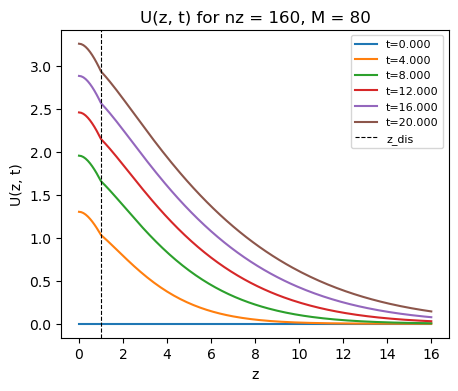

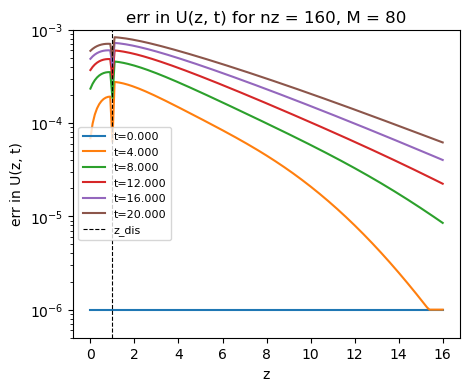

In [6]:

# pick 6 evenly-spaced time levels (skip t=0)
idx = torch.linspace(0, M2, 6).long()

plt.figure(figsize=(5,4))
for i in idx:
    z = R2['z'].cpu()
    U = R2['U_out'][:, i].cpu()
    plt.plot(z, U, label=f't={R2['t_out'][i]:.3f}')
plt.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
plt.xlabel('z')
plt.ylabel('U(z, t)')
plt.title(f'U(z, t) for nz = {nz2}, M = {M2}')
plt.legend(fontsize=8)
plt.show()

plt.figure(figsize=(5,4))
for i in idx:
    z = R2['z'].cpu()
    err = torch.clip((R2['U_out'][:, i]-R['U_out'][0::2, 2*i]).abs().cpu(), min=1e-6, max=None)
    plt.semilogy(z, err, label=f't={R2['t_out'][i]:.3f}')
plt.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
plt.xlabel('z')
plt.ylabel('err in U(z, t)')
plt.ylim(0.5e-6,1e-3)
plt.title(f'err in U(z, t) for nz = {nz2}, M = {M2}')
plt.legend(fontsize=8)
plt.show()


In [7]:
%%time 
nz = 640; M = 320
R= solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True)

nz2 = nz//2; M2 = M//2
R2 = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz2, tf, device, M2, verbose=True)


device: cuda,  nz=640,  tf=20.0,  M=320
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  dt=1.5625e-04  nt_num=130000  tf_num = 20.3125
nt_skip=400  delta=0.062500
t_out.shape = torch.Size([326]),  U_out.shape = torch.Size([641, 326])

device: cuda,  nz=320,  tf=20.0,  M=160
Interface alignment error: 0.00e+00
dt_stab=6.2500e-04  dt=6.2500e-04  nt_num=33000  tf_num = 20.625
nt_skip=200  delta=0.125000
t_out.shape = torch.Size([166]),  U_out.shape = torch.Size([321, 166])

CPU times: user 28.1 s, sys: 31.1 ms, total: 28.1 s
Wall time: 28.1 s


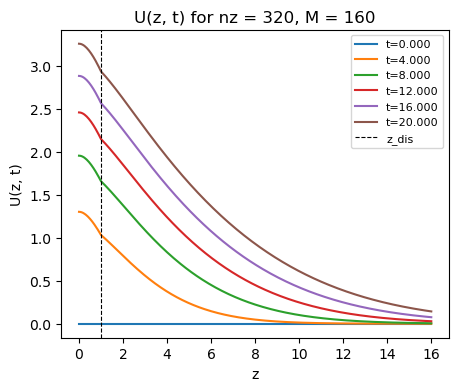

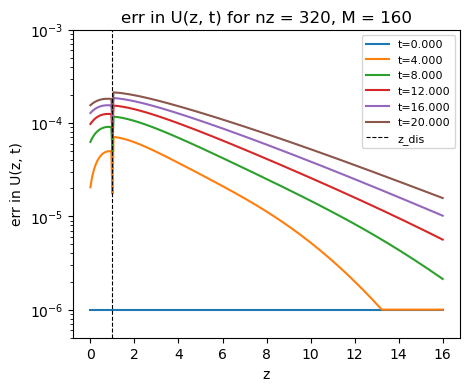

In [8]:

# pick 6 evenly-spaced time levels (skip t=0)
idx = torch.linspace(0, M2, 6).long()

plt.figure(figsize=(5,4))
for i in idx:
    z = R2['z'].cpu()
    U = R2['U_out'][:, i].cpu()
    plt.plot(z, U, label=f't={R2['t_out'][i]:.3f}')
plt.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
plt.xlabel('z')
plt.ylabel('U(z, t)')
plt.title(f'U(z, t) for nz = {nz2}, M = {M2}')
plt.legend(fontsize=8)
plt.show()

plt.figure(figsize=(5,4))
for i in idx:
    z = R2['z'].cpu()
    err = torch.clip((R2['U_out'][:, i]-R['U_out'][0::2, 2*i]).abs().cpu(), min=1e-6, max=None)
    plt.semilogy(z, err, label=f't={R2['t_out'][i]:.3f}')
plt.axvline(z_dis, color='k', linestyle='--', lw=0.8, label='z_dis')
plt.xlabel('z')
plt.ylabel('err in U(z, t)')
plt.ylim(0.5e-6,1e-3)
plt.title(f'err in U(z, t) for nz = {nz2}, M = {M2}')
plt.legend(fontsize=8)
plt.show()
